## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

## 3. TÍNH RFM

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)

customer = df_success.groupby('Customer ID').agg({
    'Country': 'first',
    'InvoiceDate': lambda x: (now - x.max()).days,
    'Amount': 'sum',
    'Invoice': 'nunique'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Amount': 'Monetary',
    'Invoice': 'Frequency'
})

print(f"Tổng số khách hàng: {len(customer)}")
print(f"\nThống kê RFM:")
print(customer[['Recency', 'Monetary', 'Frequency']].describe())

Tổng số khách hàng: 4314

Thống kê RFM:
           Recency       Monetary    Frequency
count  4314.000000    4314.000000  4314.000000
mean     91.269124    2047.288659     4.454103
std      96.943482    8912.523243     8.168658
min       1.000000       0.000000     1.000000
25%      18.000000     307.950000     1.000000
50%      53.000000     705.550000     2.000000
75%     136.000000    1722.802500     5.000000
max     374.000000  349164.350000   205.000000


## 4. XỬ LÝ DỮ LIỆU CHO CLUSTERING

In [5]:
# Sử dụng log transform để giảm thiểu ảnh hưởng của outlier
rfm_log = customer.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

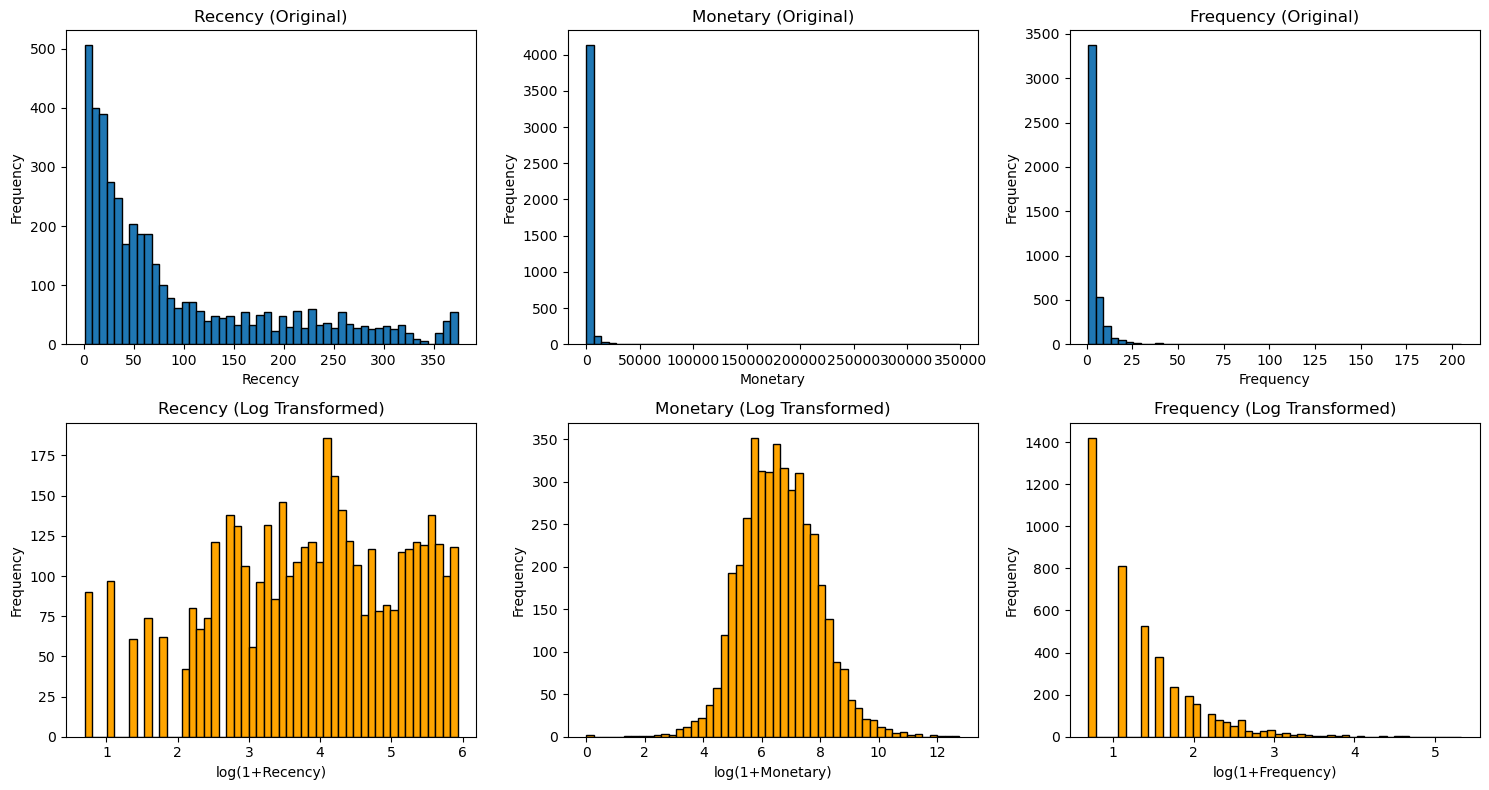

In [6]:
# Visualize phân phối trước và sau log
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Recency', 'Monetary', 'Frequency']

for i, feature in enumerate(features):
    # Original
    axes[0, i].hist(customer[feature], bins=50, edgecolor='black')
    axes[0, i].set_title(f'{feature} (Original)')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Frequency')
    
    # Log transformed
    axes[1, i].hist(rfm_log[feature], bins=50, edgecolor='black', color='orange')
    axes[1, i].set_title(f'{feature} (Log Transformed)')
    axes[1, i].set_xlabel(f'log(1+{feature})')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
# Chuẩn hóa
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Monetary', 'Frequency']])
rfm_scaled = pd.DataFrame(
    rfm_scaled, 
    columns=['Recency', 'Monetary', 'Frequency'], 
    index=rfm_log.index
)

## 5. TÌM K TỐI ƯU

In [8]:
K_range = range(2, 11)
wcss = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(rfm_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(rfm_scaled, labels))

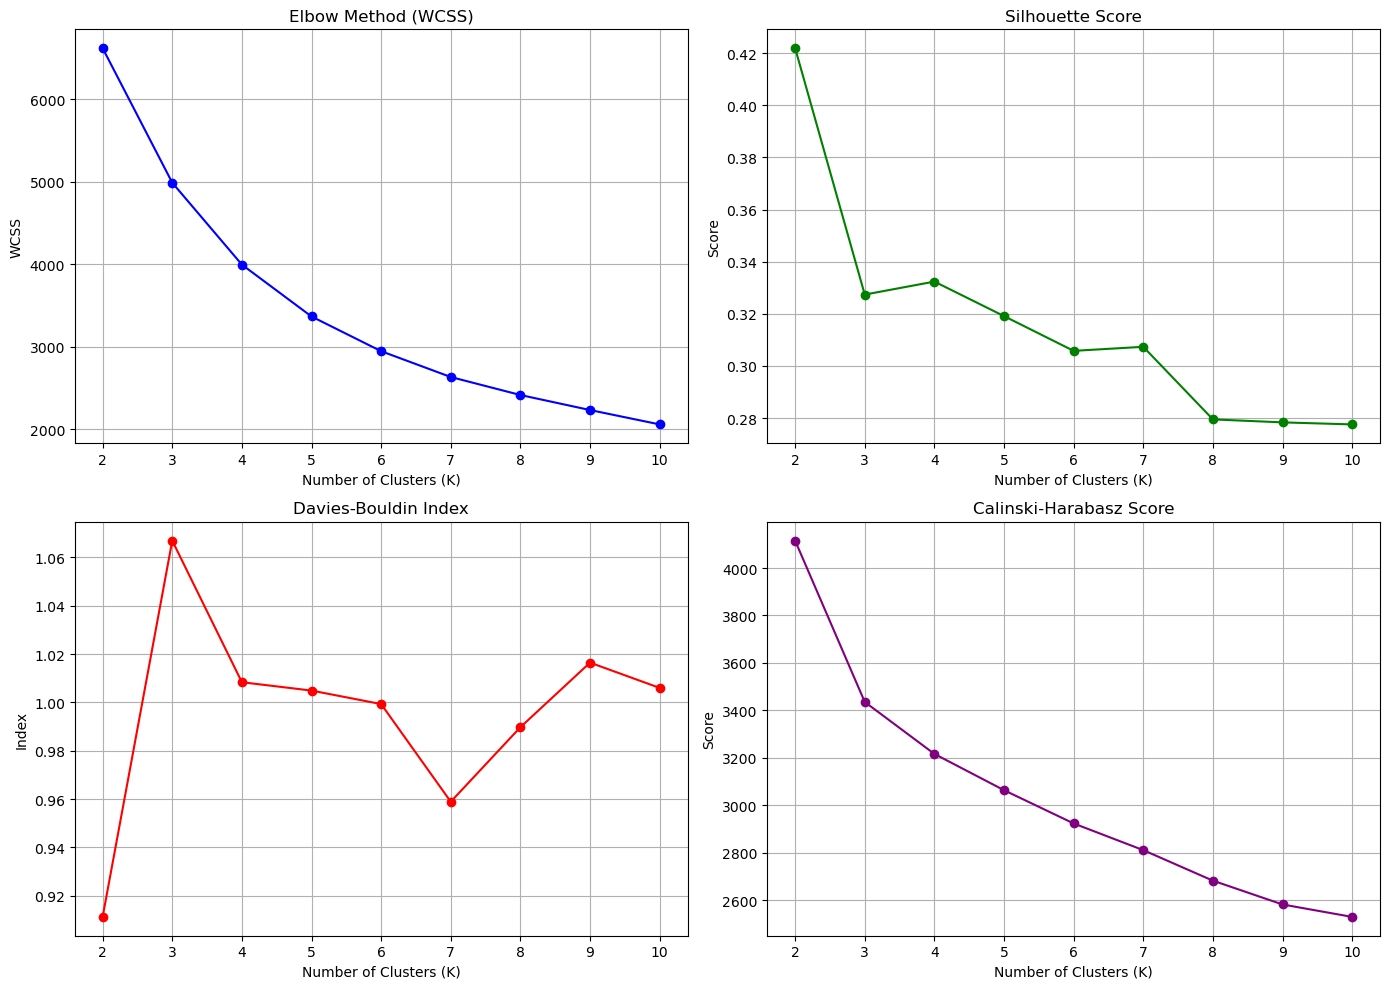

In [9]:
# Vẽ biểu đồ các metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_range, wcss, marker='o', color='blue')
axes[0, 0].set_title('Elbow Method (WCSS)')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].grid(True)

axes[0, 1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True)

axes[1, 0].plot(K_range, davies_bouldin_scores, marker='o', color='red')
axes[1, 0].set_title('Davies-Bouldin Index')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Index')
axes[1, 0].grid(True)

axes[1, 1].plot(K_range, calinski_harabasz_scores, marker='o', color='purple')
axes[1, 1].set_title('Calinski-Harabasz Score')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 6. CHỌN K DỰA TRÊN METRIC

In [10]:
metric_df = pd.DataFrame({
    'K': K_range,
    'WCSS': wcss,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores,
    'Calinski-Harabasz': calinski_harabasz_scores
})
print("\nBảng tổng hợp các metrics:")
print(metric_df.round(4))

optimal_k = 3
print(f"\nChọn K = {optimal_k}")


Bảng tổng hợp các metrics:
    K       WCSS  Silhouette  Davies-Bouldin  Calinski-Harabasz
0   2  6621.9117      0.4219          0.9113          4115.4730
1   3  4989.5689      0.3274          1.0670          3435.4801
2   4  3995.9181      0.3324          1.0084          3216.4167
3   5  3366.9463      0.3191          1.0049          3063.5783
4   6  2946.0794      0.3058          0.9993          2923.3962
5   7  2632.7901      0.3073          0.9589          2810.8338
6   8  2414.5012      0.2795          0.9898          2682.1509
7   9  2232.2071      0.2784          1.0165          2581.8511
8  10  2057.9068      0.2776          1.0060          2529.3684

Chọn K = 3


## 7. PHÂN CỤM VỚI K TỐI ƯU

In [11]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled)

## 8. PHÂN TÍCH ĐẶC ĐIỂM TỪNG CLUSTER

In [12]:
cluster_summary_scaled = rfm_scaled.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].mean()
print("\nĐặc điểm các cluster (dữ liệu đã chuẩn hóa):")
print(cluster_summary_scaled.round(4))

customer['Cluster'] = rfm_scaled['Cluster']
cluster_summary_original = customer.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median'])
print("\nĐặc điểm các cluster (dữ liệu gốc):")
print(cluster_summary_original.round(2))


Đặc điểm các cluster (dữ liệu đã chuẩn hóa):
         Recency  Monetary  Frequency
Cluster                              
0         0.7394   -0.8584    -0.8136
1        -0.2020    0.2241     0.0638
2        -1.1095    1.3104     1.5612

Đặc điểm các cluster (dữ liệu gốc):
        Recency        Monetary          Frequency       
           mean median     mean   median      mean median
Cluster                                                  
0        164.29  157.5   322.65   262.15      1.30    1.0
1         54.31   38.0  1282.67   977.43      3.38    3.0
2         18.23   10.0  7289.70  3446.46     13.33    9.0


## 9. GÁN NHÃN PHÂN KHÚC

In [13]:
def assign_segment(cluster_id):
    cluster_data = cluster_summary_scaled.loc[cluster_id]
    
    monetary_rank = cluster_summary_scaled['Monetary'].rank(ascending=False).loc[cluster_id]
    recency_rank = cluster_summary_scaled['Recency'].rank(ascending=True).loc[cluster_id]
    frequency_rank = cluster_summary_scaled['Frequency'].rank(ascending=False).loc[cluster_id]
    
    if monetary_rank == 1 and recency_rank <= 2 and frequency_rank <= 2:
        return 'The Elite'
    elif monetary_rank == 2 and recency_rank <= 2:
        return 'The Loyalists'
    elif monetary_rank == optimal_k or recency_rank == optimal_k:
        return 'Need Attention'
    else:
        return 'The High-Potential'

customer['Segment'] = customer['Cluster'].apply(assign_segment)

## 10. TRỰC QUAN HÓA KẾT QUẢ PCA

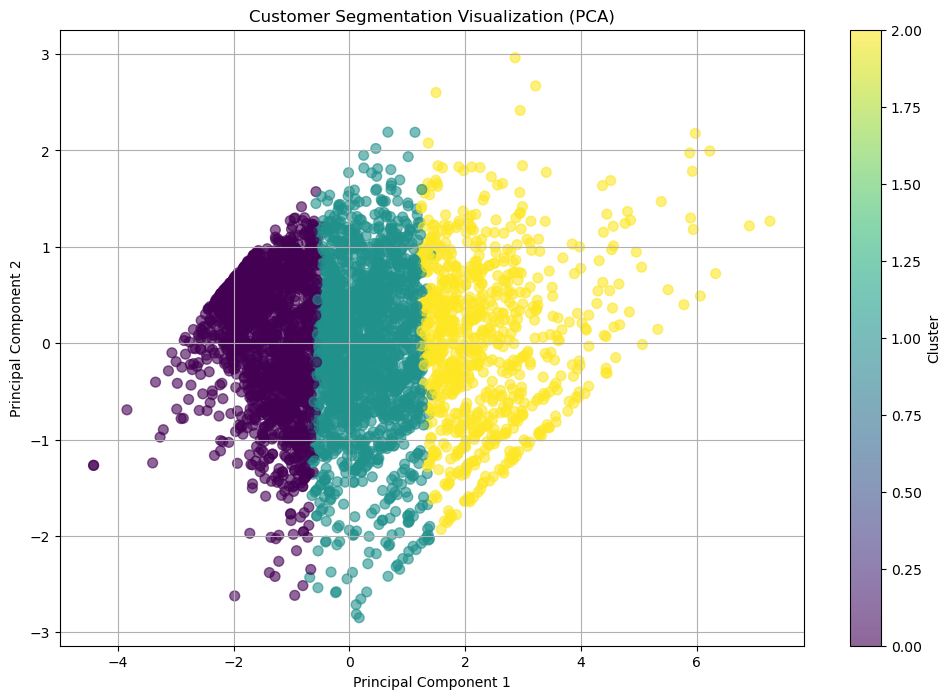

In [15]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled[['Recency', 'Monetary', 'Frequency']])
rfm_scaled['PCA1'] = rfm_pca[:, 0]
rfm_scaled['PCA2'] = rfm_pca[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    rfm_scaled['PCA1'], 
    rfm_scaled['PCA2'], 
    c=rfm_scaled['Cluster'], 
    cmap='viridis', 
    alpha=0.6,
    s=50
)
plt.title('Customer Segmentation Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

## 11. PHÂN BỔ KHÁCH HÀNG THEO TỪNG SEGMENT


PHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:
Segment
The Loyalists     1770
Need Attention    1720
The Elite          824
Name: count, dtype: int64

Tỷ lệ phần trăm:
Segment
The Loyalists     41.0
Need Attention    39.9
The Elite         19.1
Name: count, dtype: float64


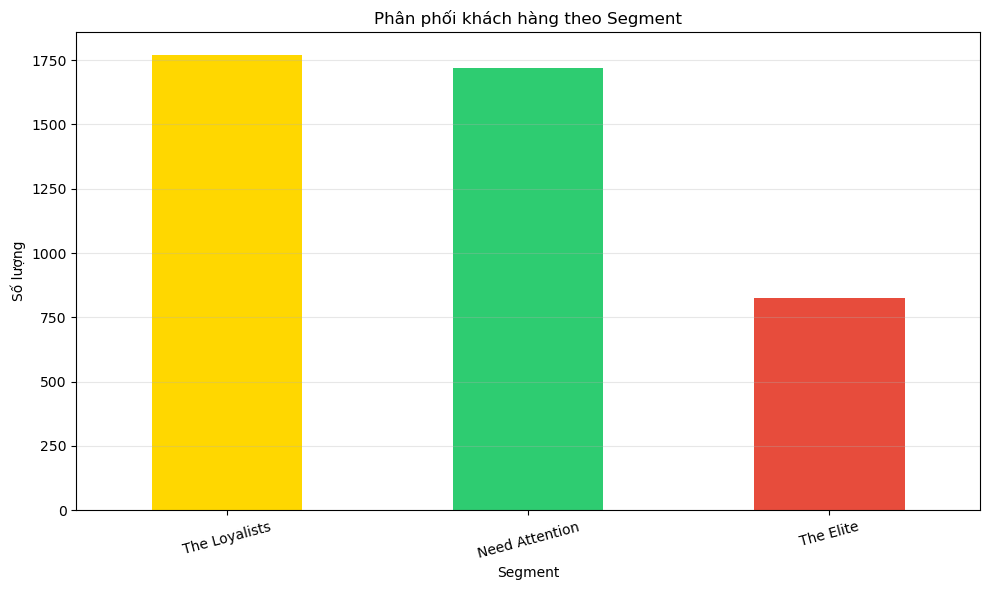

In [16]:
segment_counts = customer['Segment'].value_counts()
print("\nPHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:")
print(segment_counts)
print(f"\nTỷ lệ phần trăm:")
print((segment_counts / len(customer) * 100).round(1))

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color=['#FFD700', '#2ECC71', '#E74C3C', '#3498DB'])
plt.title('Phân phối khách hàng theo Segment')
plt.xlabel('Segment')
plt.ylabel('Số lượng')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. CHI TIẾT TỪNG SEGMENT

In [17]:
segment_profile = customer.groupby('Segment')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median', 'std'])
print("\nĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:")
print(segment_profile.round(2))


ĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:
               Recency                Monetary                    Frequency  \
                  mean median     std     mean   median       std      mean   
Segment                                                                       
Need Attention  164.29  157.5  105.91   322.65   262.15    255.78      1.30   
The Elite        18.23   10.0   24.73  7289.70  3446.46  19445.51     13.33   
The Loyalists    54.31   38.0   51.89  1282.67   977.43   1185.57      3.38   

                              
               median    std  
Segment                       
Need Attention    1.0   0.59  
The Elite         9.0  15.54  
The Loyalists     3.0   1.58  


## 13. EXPORT MODEL & KẾT QUẢ

In [19]:
customer.to_csv('../data/customer_segmented.csv', index=True)
print("\nĐã lưu file 'customer_segmented.csv'")

import joblib
model_artifacts = {
    'scaler': scaler,
    'kmeans': kmeans,
    'pca': pca,
    'segment_mapping': dict(zip(range(optimal_k), customer.groupby('Cluster')['Segment'].first().values))
}
joblib.dump(model_artifacts, '../models/clustering_model.pkl')
print("Đã lưu model 'clustering_model.pkl'")


Đã lưu file 'customer_segmented.csv'
Đã lưu model 'clustering_model.pkl'


## 14. TOP KHÁCH HÀNG

In [20]:
top_customers = customer.nlargest(5, 'Monetary')
print("\nTOP 5 KHÁCH HÀNG THEO MONETARY:")
print(top_customers[['Recency', 'Monetary', 'Frequency', 'Segment']])


TOP 5 KHÁCH HÀNG THEO MONETARY:
             Recency   Monetary  Frequency    Segment
Customer ID                                          
18102.0            1  349164.35         89  The Elite
14646.0           10  248396.50         78  The Elite
14156.0            7  196566.74        102  The Elite
14911.0            1  152147.57        205  The Elite
13694.0            9  131443.19         94  The Elite
